# Notebook 06 — Optimisation énergétique du système SWRO

**PFE — Master Science des Données**

## Objectif

Utiliser le **modèle MLP optimisé** du Notebook 04 comme fonction de prédiction afin de rechercher des conditions de fonctionnement donnant une **SEC minimale (kWh/m³)**.

L'optimisation est réalisée sous contraintes afin d'éviter des solutions manifestement irréalistes.

> **Important :** ce notebook optimise le modèle appris sur les données synthétiques. Il ne constitue pas à lui seul une preuve qu'une configuration est physiquement optimale sur une vraie station. Les solutions doivent être vérifiées avec le modèle physique et les contraintes d'exploitation.

In [1]:
# 0. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from scipy.optimize import differential_evolution, minimize

MODEL_DIR = Path("models")
DATA_DIR = Path("data/preprocessed")
RESULT_DIR = Path("results")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_model_optimized.pkl"

FEATURES = [
    "pressure_bar",
    "feed_flow_m3_h",
    "salinity_g_L",
    "temperature_C",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
    "membrane_condition",
]

print("Configuration chargée.")

Configuration chargée.


## 1. Charger le modèle final et les données

Le modèle final provient du Notebook 04. Les données servent ici à récupérer les plages réellement observées dans le dataset synthétique.

In [2]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modèle introuvable : {MODEL_PATH}. Exécutez le Notebook 04."
    )

model = joblib.load(MODEL_PATH)

X_train = pd.read_csv(DATA_DIR / "X_train_scaled.csv")
X_test = pd.read_csv(DATA_DIR / "X_test_scaled.csv")

print("Modèle :", type(model).__name__)
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

Modèle : MLPRegressor
X_train : (7000, 8)
X_test : (1500, 8)


C:\Users\ilias\miniconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# 2. Définir les contraintes d'optimisation

Par défaut, les bornes sont calculées à partir du dataset.

Pour les variables de fonctionnement, nous utilisons les quantiles 1 % et 99 % afin d'éviter que quelques valeurs extrêmes dominent l'optimisation.

**À adapter dans le mémoire** si des limites réelles de la station sont disponibles.

In [3]:
# Bornes automatiques à partir des données
bounds_df = pd.DataFrame({
    "min": X_train[FEATURES].quantile(0.01),
    "max": X_train[FEATURES].quantile(0.99)
})

display(bounds_df)

# IMPORTANT :
# Les données sont standardisées dans X_train.
# Les bornes ci-dessus sont donc exprimées dans l'espace standardisé.
# Le modèle final attend également cet espace.

bounds = [
    (float(bounds_df.loc[f, "min"]), float(bounds_df.loc[f, "max"]))
    for f in FEATURES
]

print("Nombre de variables optimisées :", len(bounds))

,min,max
pressure_bar,-1.670129,1.727311
feed_flow_m3_h,-1.708316,1.677685
salinity_g_L,-1.697566,1.713508
temperature_C,-1.691743,1.699060
recovery_rate_target,-1.688533,1.718569
pump_efficiency,-1.709124,1.689921
erd_efficiency,-1.706205,1.695860
membrane_condition,-1.714706,1.717157


Nombre de variables optimisées : 8


# 3. Fonction objectif

La fonction objectif est :

\[
\min_x \; \widehat{SEC}(x)
\]

où `x` représente les conditions de fonctionnement et `SEĈ` est la prédiction du modèle ML.

In [4]:
def objective(x):
    X = pd.DataFrame([x], columns=FEATURES)
    prediction = float(model.predict(X)[0])
    return prediction

# Test de la fonction
x0 = X_train[FEATURES].median().values
print("SEC au point médian :", objective(x0), "kWh/m³")

SEC au point médian : 3.556845713031128 kWh/m³


# 4. Contraintes supplémentaires

Nous ajoutons des pénalités pour empêcher certaines combinaisons incohérentes.

Dans cette première version, nous imposons principalement :

- `pump_efficiency` > 0
- `erd_efficiency` > 0
- `recovery_rate_target` > 0

Les limites exactes doivent ensuite être remplacées par les contraintes physiques de la station si elles sont disponibles.

In [5]:
# Seuils minimaux dans l'espace des données
MIN_POSITIVE = 1e-6

idx = {f:i for i, f in enumerate(FEATURES)}

def constrained_objective(x):
    penalty = 0.0

    # Les variables d'efficacité et de récupération doivent rester positives
    if x[idx["pump_efficiency"]] <= MIN_POSITIVE:
        penalty += 100.0
    if x[idx["erd_efficiency"]] <= MIN_POSITIVE:
        penalty += 100.0
    if x[idx["recovery_rate_target"]] <= MIN_POSITIVE:
        penalty += 100.0

    # Le modèle reste la fonction principale
    return objective(x) + penalty

print("Fonction objectif contrainte prête.")

Fonction objectif contrainte prête.


# 5. Optimisation globale — Differential Evolution

`Differential Evolution` explore globalement l'espace de recherche et ne nécessite pas de dérivée.

C'est adapté ici car le MLP est une fonction non linéaire.

In [6]:
result_de = differential_evolution(
    constrained_objective,
    bounds=bounds,
    seed=42,
    maxiter=300,
    popsize=15,
    tol=1e-7,
    polish=True,
    workers=1
)

print("Optimisation terminée.")
print("Succès :", result_de.success)
print("Message :", result_de.message)
print("SEC prédite minimale :", result_de.fun, "kWh/m³")

Optimisation terminée.
Succès : False
Message : Maximum number of iterations has been exceeded.
SEC prédite minimale : 2.206382422852499 kWh/m³


# 6. Solution optimale trouvée

In [7]:
x_opt = result_de.x

optimal_solution_scaled = pd.DataFrame(
    [x_opt],
    columns=FEATURES
)

optimal_sec = objective(x_opt)

display(optimal_solution_scaled)

print(f"SEC prédite optimale : {optimal_sec:.6f} kWh/m³")

,pressure_bar,feed_flow_m3_h,salinity_g_L,temperature_C,recovery_rate_target,pump_efficiency,erd_efficiency,membrane_condition
0,-1.670129,1.677685,1.713508,-1.691743,1.718569,1.689921,1.69586,-1.714706


SEC prédite optimale : 2.206382 kWh/m³


# 7. Comparaison avec le fonctionnement médian

Pour quantifier le gain, nous comparons la solution optimisée au point médian du dataset.

In [8]:
x_baseline = X_train[FEATURES].median().values

baseline_sec = objective(x_baseline)
optimized_sec = objective(x_opt)

absolute_gain = baseline_sec - optimized_sec
relative_gain = absolute_gain / baseline_sec * 100

comparison = pd.DataFrame([
    {
        "Scenario": "Fonctionnement médian",
        "Predicted_SEC_kWh_m3": baseline_sec
    },
    {
        "Scenario": "Optimisé",
        "Predicted_SEC_kWh_m3": optimized_sec
    }
])

display(comparison)

print(f"Gain absolu : {absolute_gain:.6f} kWh/m³")
print(f"Gain relatif : {relative_gain:.2f} %")

,Scenario,Predicted_SEC_kWh_m3
0,Fonctionnement médian,3.556846
1,Optimisé,2.206382


Gain absolu : 1.350463 kWh/m³
Gain relatif : 37.97 %


# 8. Comparaison variable par variable

Cette table montre comment l'optimisation modifie les conditions de fonctionnement par rapport au point médian.

In [9]:
variables_comparison = pd.DataFrame({
    "Feature": FEATURES,
    "Median": x_baseline,
    "Optimized": x_opt,
})

variables_comparison["Delta"] = (
    variables_comparison["Optimized"]
    - variables_comparison["Median"]
)

display(variables_comparison)

,Feature,Median,Optimized,Delta
0,pressure_bar,-0.002808,-1.670129,-1.667321
1,feed_flow_m3_h,0.004148,1.677685,1.673537
2,salinity_g_L,0.001808,1.713508,1.711701
3,temperature_C,0.011332,-1.691743,-1.703075
4,recovery_rate_target,-0.012422,1.718569,1.730991
5,pump_efficiency,0.008093,1.689921,1.681828
6,erd_efficiency,0.010064,1.695860,1.685795
7,membrane_condition,0.006124,-1.714706,-1.720830


# 9. Sensibilité locale autour de la solution optimale

Nous faisons varier une variable à la fois autour de la solution trouvée pour observer son effet sur la SEC prédite.

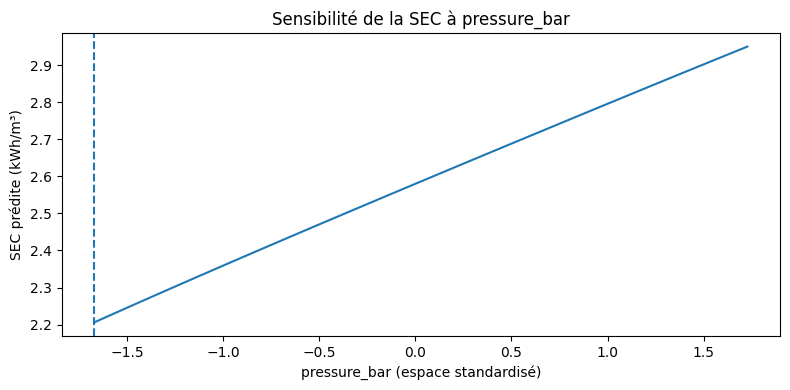

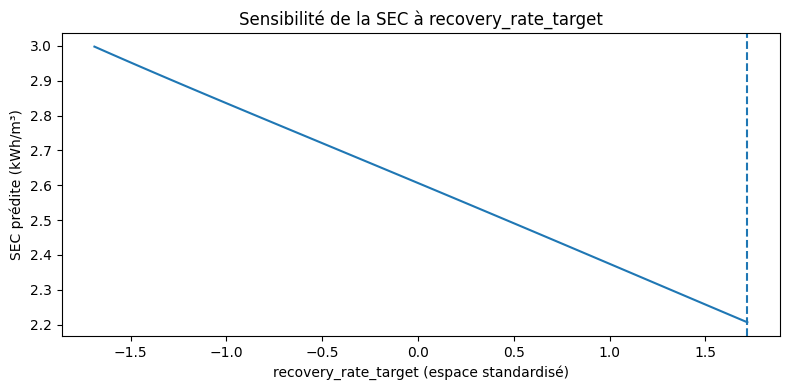

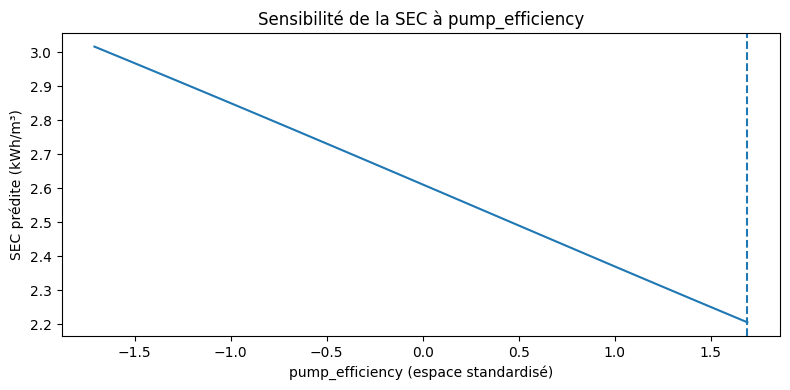

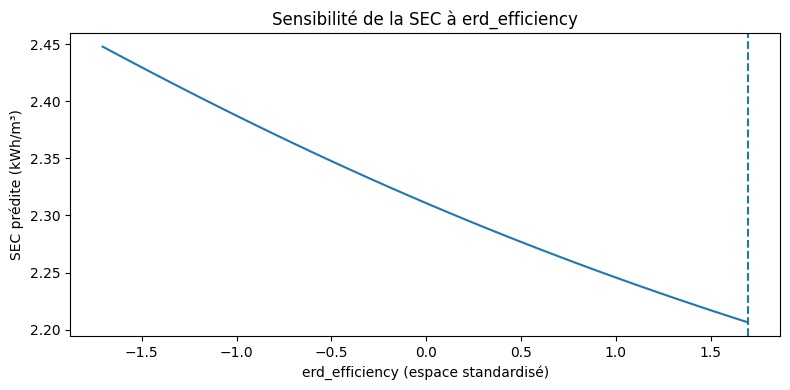

In [10]:
top_features = [
    "pressure_bar",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency"
]

for feature in top_features:
    j = idx[feature]
    low, high = bounds[j]

    values = np.linspace(low, high, 80)
    X_grid = np.tile(x_opt, (len(values), 1))
    X_grid[:, j] = values

    preds = model.predict(
        pd.DataFrame(X_grid, columns=FEATURES)
    )

    plt.figure(figsize=(8, 4))
    plt.plot(values, preds)
    plt.axvline(x_opt[j], linestyle="--")
    plt.xlabel(f"{feature} (espace standardisé)")
    plt.ylabel("SEC prédite (kWh/m³)")
    plt.title(f"Sensibilité de la SEC à {feature}")
    plt.tight_layout()
    plt.show()

# 10. Robustesse de la solution

Une solution optimale unique peut être fragile. Nous testons donc des perturbations aléatoires autour de la solution optimale.

Une faible dispersion de la SEC indique une solution relativement robuste.

SEC moyenne : 2.2287396693744497
SEC médiane : 2.2251997071813183
SEC min : 2.2063824228524993
SEC max : 2.3256609158083283
Écart-type : 0.016147937977984972


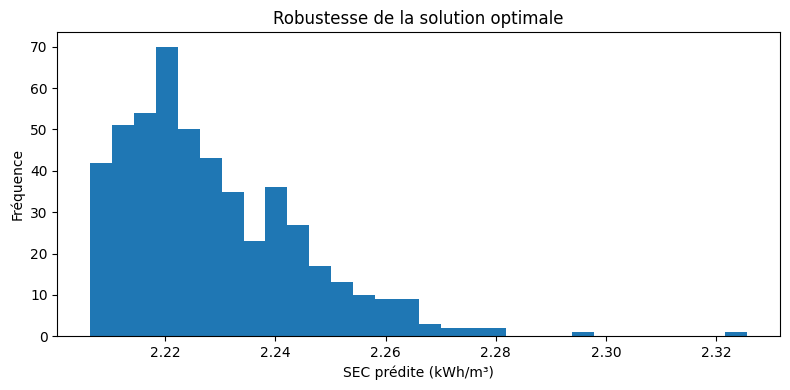

In [11]:
rng = np.random.default_rng(42)

N_ROBUSTNESS = 500
X_robust = np.tile(x_opt, (N_ROBUSTNESS, 1))

# Perturbation modérée : 2 % de l'étendue de chaque variable
for j, (low, high) in enumerate(bounds):
    scale = 0.02 * (high - low)
    X_robust[:, j] += rng.normal(0, scale, N_ROBUSTNESS)
    X_robust[:, j] = np.clip(
        X_robust[:, j],
        low,
        high
    )

robust_predictions = model.predict(
    pd.DataFrame(X_robust, columns=FEATURES)
)

print("SEC moyenne :", robust_predictions.mean())
print("SEC médiane :", np.median(robust_predictions))
print("SEC min :", robust_predictions.min())
print("SEC max :", robust_predictions.max())
print("Écart-type :", robust_predictions.std())

plt.figure(figsize=(8, 4))
plt.hist(robust_predictions, bins=30)
plt.xlabel("SEC prédite (kWh/m³)")
plt.ylabel("Fréquence")
plt.title("Robustesse de la solution optimale")
plt.tight_layout()
plt.show()

# 11. Validation croisée de la solution par rapport au dataset

Nous vérifions si la solution optimale reste dans les plages observées.

Cette étape est essentielle : le modèle est fiable principalement dans la région où il a été entraîné.

In [12]:
inside_dataset = []

for feature in FEATURES:
    value = x_opt[idx[feature]]
    fmin = X_train[feature].min()
    fmax = X_train[feature].max()

    inside_dataset.append({
        "Feature": feature,
        "Optimized": value,
        "Observed_Min": fmin,
        "Observed_Max": fmax,
        "Inside_Observed_Range": fmin <= value <= fmax
    })

domain_check = pd.DataFrame(inside_dataset)

display(domain_check)

print(
    "Toutes les variables sont dans la plage observée :",
    domain_check["Inside_Observed_Range"].all()
)

,Feature,Optimized,Observed_Min,Observed_Max,Inside_Observed_Range
0,pressure_bar,-1.670129,-1.709626,1.760858,True
1,feed_flow_m3_h,1.677685,-1.741327,1.706395,True
2,salinity_g_L,1.713508,-1.735927,1.742177,True
3,temperature_C,-1.691743,-1.720754,1.733982,True
4,recovery_rate_target,1.718569,-1.719336,1.747355,True
5,pump_efficiency,1.689921,-1.742756,1.723602,True
6,erd_efficiency,1.695860,-1.741793,1.727834,True
7,membrane_condition,-1.714706,-1.743899,1.753002,True


Toutes les variables sont dans la plage observée : True


# 12. Recherche d'une solution alternative robuste

Une optimisation pure peut pousser les variables vers les frontières. Pour une décision opérationnelle, nous cherchons également une solution proche de l'optimum mais plus éloignée des extrêmes.

On ajoute une petite pénalisation de distance par rapport au centre des plages observées.

In [13]:
centers = np.array([
    (low + high) / 2
    for low, high in bounds
])

half_ranges = np.array([
    (high - low) / 2
    for low, high in bounds
])

def robust_objective(x):
    sec = objective(x)

    normalized_distance = np.mean(
        ((x - centers) / (half_ranges + 1e-12)) ** 2
    )

    # Petite pénalisation : priorité à la SEC, mais évite les solutions extrêmes
    return sec + 0.01 * normalized_distance

result_robust = differential_evolution(
    robust_objective,
    bounds=bounds,
    seed=42,
    maxiter=250,
    popsize=12,
    tol=1e-7,
    polish=True,
    workers=1
)

x_robust = result_robust.x
robust_sec = objective(x_robust)

print("SEC solution robuste :", robust_sec, "kWh/m³")

robust_solution = pd.DataFrame({
    "Feature": FEATURES,
    "Optimized_Robust": x_robust,
    "Median": x_baseline
})

display(robust_solution)

SEC solution robuste : 2.206382422852499 kWh/m³


,Feature,Optimized_Robust,Median
0,pressure_bar,-1.670129,-0.002808
1,feed_flow_m3_h,1.677685,0.004148
2,salinity_g_L,1.713508,0.001808
3,temperature_C,-1.691743,0.011332
4,recovery_rate_target,1.718569,-0.012422
5,pump_efficiency,1.689921,0.008093
6,erd_efficiency,1.695860,0.010064
7,membrane_condition,-1.714706,0.006124


# 13. Choix de la solution finale

Nous conservons deux scénarios :

- **Optimum ML** : SEC minimale prédite ;
- **Optimum robuste** : compromis entre SEC et éloignement des extrêmes.

Le choix opérationnel doit être validé par le modèle physique et les contraintes réelles.

,Scenario,Predicted_SEC_kWh_m3
0,Baseline median,3.556846
1,ML optimum,2.206382
2,Robust optimum,2.206382


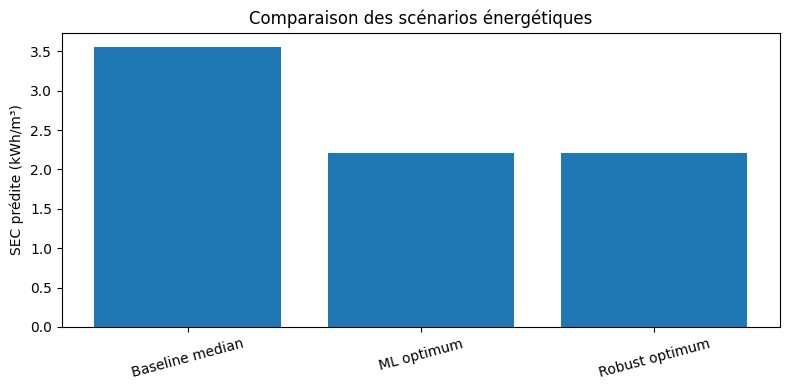

In [14]:
final_solutions = pd.DataFrame([
    {
        "Scenario": "Baseline median",
        "Predicted_SEC_kWh_m3": baseline_sec
    },
    {
        "Scenario": "ML optimum",
        "Predicted_SEC_kWh_m3": optimized_sec
    },
    {
        "Scenario": "Robust optimum",
        "Predicted_SEC_kWh_m3": robust_sec
    }
])

display(final_solutions)

plt.figure(figsize=(8, 4))
plt.bar(
    final_solutions["Scenario"],
    final_solutions["Predicted_SEC_kWh_m3"]
)
plt.ylabel("SEC prédite (kWh/m³)")
plt.title("Comparaison des scénarios énergétiques")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 14. Export des résultats

Les résultats sont sauvegardés pour le mémoire et pour le futur dashboard.

In [15]:
optimal_solution_scaled.to_csv(
    RESULT_DIR / "ml_optimal_solution_scaled.csv",
    index=False
)

variables_comparison.to_csv(
    RESULT_DIR / "optimization_variable_comparison.csv",
    index=False
)

domain_check.to_csv(
    RESULT_DIR / "optimization_domain_check.csv",
    index=False
)

robust_solution.to_csv(
    RESULT_DIR / "robust_optimal_solution_scaled.csv",
    index=False
)

final_solutions.to_csv(
    RESULT_DIR / "optimization_scenarios.csv",
    index=False
)

pd.DataFrame({
    "Metric": [
        "Baseline_SEC",
        "ML_Optimum_SEC",
        "Robust_Optimum_SEC",
        "ML_Absolute_Gain",
        "ML_Relative_Gain_percent"
    ],
    "Value": [
        baseline_sec,
        optimized_sec,
        robust_sec,
        absolute_gain,
        relative_gain
    ]
}).to_csv(
    RESULT_DIR / "optimization_metrics.csv",
    index=False
)

print("Résultats sauvegardés dans :", RESULT_DIR.resolve())

Résultats sauvegardés dans : C:\Users\ilias\OneDrive\Documents\PFE\desalement\results


# 15. Interprétation scientifique

Le résultat principal doit être présenté sous la forme :

> Le modèle MLP optimisé a été utilisé comme fonction objectif afin de rechercher une configuration minimisant la SEC. Une comparaison avec un fonctionnement de référence et une analyse de robustesse permettent d'évaluer le gain prédit.

### Attention

Un résultat du type :

`SEC optimale = X kWh/m³`

est une **prédiction du modèle**, pas une mesure réelle.

Avant de recommander cette configuration sur une vraie station, il faut vérifier :

1. les limites de pression ;
2. le taux de récupération admissible ;
3. l'efficacité réelle de la pompe ;
4. l'efficacité réelle de l'ERD ;
5. les contraintes de membrane ;
6. la qualité de l'eau d'alimentation ;
7. les contraintes hydrauliques et de sécurité.

## Étape suivante

**Notebook 07 — Validation physique + comparaison avant/après optimisation**

Nous allons confronter la solution trouvée par ML au modèle physique synthétique afin d'éviter une optimisation purement mathématique.